# Spotify Data Analysis

## Introduction
Music streaming platforms such as Spotify generate large amounts of data about songs, artists, and listener preferences. This data can be analyzed to understand trends in popular music and identify the characteristics that contribute to a song’s success. By examining different musical features and track information, we can gain insights into what makes certain songs more popular than others.

In this project, we analyze the **Spotify Top 50 Tracks dataset from 2020**, which contains information about the most streamed songs on the platform during that year. The dataset includes several audio features such as danceability, energy, loudness, acousticness, and tempo, which help describe the musical qualities of each track.

The main goal of this analysis is to perform **Exploratory Data Analysis (EDA)** in order to identify patterns in popular music, examine relationships between musical features, and understand the characteristics of successful songs in the streaming era.

---

## Dataset Overview

This dataset contains information about the **Top 50 most streamed tracks on Spotify in 2020**.

**Dataset Size**
- 50 songs
- 16 variables

### Numerical Variables
These variables represent measurable musical characteristics of each track:

- **Energy** – Measure of intensity and activity *(range: 0–1)*
- **Danceability** – How suitable a track is for dancing *(range: 0–1)*
- **Instrumentalness** – Probability that the track contains no vocals *(range: 0–1)*
- **Valence** – Musical positivity conveyed by the track *(range: 0–1)*
- **Acousticness** – Confidence that the track is acoustic *(range: 0–1)*
- **Duration_ms** – Duration of the track in milliseconds *(typically 200k–400k)*
- **Liveness** – Presence of a live audience *(range: 0–1)*
- **Speechiness** – Presence of spoken words *(range: 0–1)*
- **Tempo** – Speed of the track *(beats per minute)*
- **Loudness** – Overall loudness of the track *(in decibels)*

### Categorical Variables
These variables describe descriptive attributes of each song:

- **Artist** – Name of the performing artist
- **Track_name** – Title of the song
- **Key** – Musical key of the track
- **Genre** – Musical genre classification
- **Album** – Album the track belongs to

---

## Key Questions

This analysis aims to answer several important questions:

- Which **genres** are most represented in the Top 50?
- Which **artists** appear most frequently?
- Are there **artists or albums with multiple popular tracks**?
- Which songs have the **highest or lowest musical feature values**?
- Are there **relationships between audio features** such as energy, loudness, and danceability?
- How do musical features **compare across different genres**?

---

## Analysis Plan

The project will follow these main steps:

1. **Data Preparation**
   - Load the dataset
   - Explore the structure of the data
   - Handle missing values and duplicates

2. **Exploratory Data Analysis**
   - Analyze artists and albums
   - Examine musical features
   - Identify popular genres

3. **Statistical Analysis**
   - Study correlations between features
   - Compare characteristics across genres

4. **Visualization**
   - Create charts to illustrate key findings
   - Compare distributions of musical features

---

Next, we begin the analysis by **importing the necessary Python libraries and loading the dataset**.

## Import Required Libraries

Before starting the analysis, we need to import the Python libraries that will be used for data manipulation, analysis, and visualization.

- **Pandas** – for data loading and manipulation  
- **NumPy** – for numerical operations  
- **Matplotlib** – for creating visualizations  
- **Seaborn** – for statistical data visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

## Load the Dataset

In this step, we load the Spotify Top 50 dataset into a Pandas DataFrame. 
This allows us to easily explore and analyze the data using Python.

In [2]:
df = pd.read_csv("spotifytoptracks.csv")

df.head()

,Unnamed: 0,artist,album,track_name,track_id,energy,danceability,key,loudness,acousticness,speechiness,instrumentalness,liveness,valence,tempo,duration_ms,genre
0,0,The Weeknd,After Hours,Blinding Lights,0VjIjW4GlUZAMYd2vXMi3b,0.730,0.514,1,-5.934,0.00146,0.0598,0.000095,0.0897,0.334,171.005,200040,R&B/Soul
1,1,Tones And I,Dance Monkey,Dance Monkey,1rgnBhdG2JDFTbYkYRZAku,0.593,0.825,6,-6.401,0.68800,0.0988,0.000161,0.1700,0.540,98.078,209755,Alternative/Indie
2,2,Roddy Ricch,Please Excuse Me For Being Antisocial,The Box,0nbXyq5TXYPCO7pr3N8S4I,0.586,0.896,10,-6.687,0.10400,0.0559,0.000000,0.7900,0.642,116.971,196653,Hip-Hop/Rap
3,3,SAINt JHN,Roses (Imanbek Remix),Roses - Imanbek Remix,2Wo6QQD1KMDWeFkkjLqwx5,0.721,0.785,8,-5.457,0.01490,0.0506,0.004320,0.2850,0.894,121.962,176219,Dance/Electronic
4,4,Dua Lipa,Future Nostalgia,Don't Start Now,3PfIrDoz19wz7qK7tYeu62,0.793,0.793,11,-4.521,0.01230,0.0830,0.000000,0.0951,0.679,123.950,183290,Nu-disco


## Dataset Overview

Before performing any analysis, it is important to understand the structure of the dataset. 
We will check the number of rows and columns, the data types of each variable, and basic statistical summaries.

In [3]:
df.shape

(50, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        50 non-null     int64  
 1   artist            50 non-null     object 
 2   album             50 non-null     object 
 3   track_name        50 non-null     object 
 4   track_id          50 non-null     object 
 5   energy            50 non-null     float64
 6   danceability      50 non-null     float64
 7   key               50 non-null     int64  
 8   loudness          50 non-null     float64
 9   acousticness      50 non-null     float64
 10  speechiness       50 non-null     float64
 11  instrumentalness  50 non-null     float64
 12  liveness          50 non-null     float64
 13  valence           50 non-null     float64
 14  tempo             50 non-null     float64
 15  duration_ms       50 non-null     int64  
 16  genre             50 non-null     object 
dtyp

In [5]:
df = df.drop(columns=["Unnamed: 0"])

In [6]:
df.head()

,artist,album,track_name,track_id,energy,danceability,key,loudness,acousticness,speechiness,instrumentalness,liveness,valence,tempo,duration_ms,genre
0,The Weeknd,After Hours,Blinding Lights,0VjIjW4GlUZAMYd2vXMi3b,0.730,0.514,1,-5.934,0.00146,0.0598,0.000095,0.0897,0.334,171.005,200040,R&B/Soul
1,Tones And I,Dance Monkey,Dance Monkey,1rgnBhdG2JDFTbYkYRZAku,0.593,0.825,6,-6.401,0.68800,0.0988,0.000161,0.1700,0.540,98.078,209755,Alternative/Indie
2,Roddy Ricch,Please Excuse Me For Being Antisocial,The Box,0nbXyq5TXYPCO7pr3N8S4I,0.586,0.896,10,-6.687,0.10400,0.0559,0.000000,0.7900,0.642,116.971,196653,Hip-Hop/Rap
3,SAINt JHN,Roses (Imanbek Remix),Roses - Imanbek Remix,2Wo6QQD1KMDWeFkkjLqwx5,0.721,0.785,8,-5.457,0.01490,0.0506,0.004320,0.2850,0.894,121.962,176219,Dance/Electronic
4,Dua Lipa,Future Nostalgia,Don't Start Now,3PfIrDoz19wz7qK7tYeu62,0.793,0.793,11,-4.521,0.01230,0.0830,0.000000,0.0951,0.679,123.950,183290,Nu-disco


In [7]:
df.shape

(50, 16)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artist            50 non-null     object 
 1   album             50 non-null     object 
 2   track_name        50 non-null     object 
 3   track_id          50 non-null     object 
 4   energy            50 non-null     float64
 5   danceability      50 non-null     float64
 6   key               50 non-null     int64  
 7   loudness          50 non-null     float64
 8   acousticness      50 non-null     float64
 9   speechiness       50 non-null     float64
 10  instrumentalness  50 non-null     float64
 11  liveness          50 non-null     float64
 12  valence           50 non-null     float64
 13  tempo             50 non-null     float64
 14  duration_ms       50 non-null     int64  
 15  genre             50 non-null     object 
dtypes: float64(9), int64(2), object(5)
memory usag

## Handling missing values.

In [9]:
missing_values = df.isnull().sum()

if missing_values.sum() == 0:
    print("No missing values found in any column.")
else:
    print("Columns with missing values: ")
    print(missing_values[missing_values > 0])

No missing values found in any column.


## Removing duplicate samples and features.


In [10]:
# Check for duplicate rows
duplicate_rows = df[df.duplicated()]

if not duplicate_rows.empty:
    print("Duplicate rows found:")
    display(duplicate_rows)
else:
    print("No duplicate rows found.")


# Check for duplicate columns
duplicate_columns = df.columns[df.T.duplicated()]

if len(duplicate_columns) > 0:
    print("Duplicate columns found:")
    print(duplicate_columns)
else:
    print("No duplicate columns found.")

No duplicate rows found.
No duplicate columns found.


## Treating Outliers

Outliers are data points that differ significantly from the majority of observations in the dataset. These extreme values can affect statistical analysis and may distort the interpretation of results.

To detect potential outliers in the dataset, we examine the numerical features using the **Interquartile Range (IQR) method**. This method identifies values that fall outside the normal range of the data distribution.

A value is considered an outlier if it satisfies:

Lower bound = Q1 − 1.5 × IQR  
Upper bound = Q3 + 1.5 × IQR

Where:
- **Q1** is the 25th percentile
- **Q3** is the 75th percentile
- **IQR = Q3 − Q1**

The following code identifies potential outliers for the numerical features in the dataset.

In [11]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} potential outliers")

energy: 0 potential outliers
danceability: 3 potential outliers
key: 0 potential outliers
loudness: 1 potential outliers
acousticness: 7 potential outliers
speechiness: 6 potential outliers
instrumentalness: 12 potential outliers
liveness: 3 potential outliers
valence: 0 potential outliers
tempo: 0 potential outliers
duration_ms: 2 potential outliers


## Number of Observations and features in the Dataset

To determine the number of observations in the dataset, we check the shape of the DataFrame. 
The number of observations corresponds to the number of rows in the dataset.

In [12]:
df.shape

(50, 16)

This means:

50 observations (rows) → the number of songs

16 features (columns) → the variables describing each song

## Which of the features are categorical?

In [13]:
categorical_columns = df.select_dtypes(include=["category", "object"]).columns

df_categorical = df[categorical_columns]

print("Categorical features:")
for feature in df_categorical:
    print(f" - {feature}")


Categorical features:
 - artist
 - album
 - track_name
 - track_id
 - genre


## Which of the features are numeric?

In [14]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical features in the dataset:")

for col in numerical_columns:
    print(f"- {col}")

Numerical features in the dataset:
- energy
- danceability
- key
- loudness
- acousticness
- speechiness
- instrumentalness
- liveness
- valence
- tempo
- duration_ms


## Are there any artists that have more than 1 popular track? If yes, which, and how many?

In [15]:
artist_counts = df['artist'].value_counts()

artists_multiple_tracks = artist_counts[artist_counts > 1]

print("Artists with more than one popular track:")
print(artists_multiple_tracks)

Artists with more than one popular track:
artist
Dua Lipa         3
Billie Eilish    3
Travis Scott     3
Harry Styles     2
Lewis Capaldi    2
Justin Bieber    2
Post Malone      2
Name: count, dtype: int64


## Most Popular Artist

To determine the most popular artist in the dataset, we identify the artist who appears most frequently in the Top 50 tracks. The artist with the highest number of songs in the dataset can be considered the most popular artist in this list.

In [16]:
artist_counts = df['artist'].value_counts()

most_popular_artist = artist_counts.idxmax()
track_count = artist_counts.max()

print(f"The most popular artist is {most_popular_artist} with {track_count} tracks in the Top 50.")

The most popular artist is Dua Lipa with 3 tracks in the Top 50.


## Total Number of Artists

Next, we determine how many unique artists appear in the Top 50 dataset. 
This helps us understand the diversity of artists represented among the most streamed songs.

In [17]:
total_artists = df['artist'].nunique()

print(f"Total number of artists in the Top 50: {total_artists}")

Total number of artists in the Top 50: 40


## Albums with Multiple Popular Tracks

We now examine whether any albums have more than one track in the Top 50. 
This helps identify albums that produced multiple highly streamed songs.

In [18]:
album_counts = df['album'].value_counts()

albums_multiple_tracks = album_counts[album_counts > 1]

print("Albums with more than one track in the Top 50:")
print(albums_multiple_tracks)

Albums with more than one track in the Top 50:
album
Future Nostalgia        3
Hollywood's Bleeding    2
Fine Line               2
Changes                 2
Name: count, dtype: int64


## Total Number of Albums

Next, we calculate the total number of unique albums represented in the Top 50 dataset.

In [19]:
total_albums = df['album'].nunique()

print(f"Total number of albums in the Top 50: {total_albums}")

Total number of albums in the Top 50: 45


## Tracks with High Danceability

Danceability describes how suitable a track is for dancing based on musical elements such as tempo and rhythm. 
Here we identify tracks with a danceability score greater than 0.7.

In [20]:
high_danceability = df[df['danceability'] > 0.7][['track_name', 'artist', 'danceability']]

high_danceability

,track_name,artist,danceability
1,Dance Monkey,Tones And I,0.825
2,The Box,Roddy Ricch,0.896
3,Roses - Imanbek Remix,SAINt JHN,0.785
4,Don't Start Now,Dua Lipa,0.793
5,ROCKSTAR (feat. Roddy Ricch),DaBaby,0.746
7,death bed (coffee for your head),Powfu,0.726
8,Falling,Trevor Daniel,0.784
10,Tusa,KAROL G,0.803
13,Blueberry Faygo,Lil Mosey,0.774
14,Intentions (feat. Quavo),Justin Bieber,0.806


## Tracks with Low Danceability

Next, we identify tracks with a danceability score lower than 0.4, indicating songs that are less suitable for dancing.

In [21]:
low_danceability = df[df['danceability'] < 0.4][['track_name', 'artist', 'danceability']]

low_danceability

,track_name,artist,danceability
44,lovely (with Khalid),Billie Eilish,0.351


## Tracks with High Loudness

Loudness measures the overall intensity of a track in decibels (dB). 
Here we identify tracks with loudness values greater than -5 dB.

In [22]:
high_loudness = df[df['loudness'] > -5][['track_name', 'artist', 'loudness']]

high_loudness

,track_name,artist,loudness
4,Don't Start Now,Dua Lipa,-4.521
6,Watermelon Sugar,Harry Styles,-4.209
10,Tusa,KAROL G,-3.280
12,Circles,Post Malone,-3.497
16,Before You Go,Lewis Capaldi,-4.858
17,Say So,Doja Cat,-4.577
21,Adore You,Harry Styles,-3.675
23,Mood (feat. iann dior),24kGoldn,-3.558
31,Break My Heart,Dua Lipa,-3.434
32,Dynamite,BTS,-4.410


## Tracks with Low Loudness

Next, we identify tracks with loudness values lower than -8 dB.

In [23]:
low_loudness = df[df['loudness'] < -8][['track_name', 'artist', 'loudness']]

low_loudness

,track_name,artist,loudness
7,death bed (coffee for your head),Powfu,-8.765
8,Falling,Trevor Daniel,-8.756
15,Toosie Slide,Drake,-8.820
20,Savage Love (Laxed - Siren Beat),Jawsh 685,-8.520
24,everything i wanted,Billie Eilish,-14.454
26,bad guy,Billie Eilish,-10.965
36,HIGHEST IN THE ROOM,Travis Scott,-8.764
44,lovely (with Khalid),Billie Eilish,-10.109
47,If the World Was Ending - feat. Julia Michaels,JP Saxe,-10.086


## Longest Track

We identify the longest track in the dataset based on the duration in milliseconds.

In [24]:
longest_track = df.loc[df['duration_ms'].idxmax()][['track_name', 'artist', 'duration_ms']]

longest_track

track_name       SICKO MODE
artist         Travis Scott
duration_ms          312820
Name: 49, dtype: object

## Shortest Track

Next, we identify the shortest track in the dataset based on duration.

In [25]:
shortest_track = df.loc[df['duration_ms'].idxmin()][['track_name', 'artist', 'duration_ms']]

shortest_track


track_name     Mood (feat. iann dior)
artist                       24kGoldn
duration_ms                    140526
Name: 23, dtype: object

## Most Popular Genre

To determine the most popular genre in the dataset, we count how many times each genre appears among the Top 50 tracks. The genre with the highest number of tracks is considered the most represented genre.

In [26]:
genre_counts = df['genre'].value_counts()

most_popular_genre = genre_counts.idxmax()
genre_count = genre_counts.max()

print(f"The most popular genre is {most_popular_genre} with {genre_count} tracks.")

The most popular genre is Pop with 14 tracks.


## Genres With Only One Song

Next, we identify genres that appear only once in the Top 50 dataset. These genres have only a single track represented.

In [27]:
single_genres = genre_counts[genre_counts == 1]

print("Genres with only one song:")
print(single_genres)

Genres with only one song:
genre
R&B/Hip-Hop alternative               1
Nu-disco                              1
Pop/Soft Rock                         1
Pop rap                               1
Hip-Hop/Trap                          1
Dance-pop/Disco                       1
Disco-pop                             1
Dreampop/Hip-Hop/R&B                  1
Alternative/reggaeton/experimental    1
Chamber pop                           1
Name: count, dtype: int64


## Total Number of Genres

We now calculate the total number of unique genres represented in the Top 50 dataset.

In [28]:
total_genres = df['genre'].nunique()

print(f"Total number of genres in the Top 50: {total_genres}")

Total number of genres in the Top 50: 16


## Feature Correlation Analysis

To understand relationships between numerical features, we compute the correlation matrix. 
Correlation values range from -1 to 1:

- Values close to **1** indicate strong positive correlation
- Values close to **-1** indicate strong negative correlation
- Values close to **0** indicate little or no correlation

In [29]:
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,energy,danceability,key,loudness,acousticness,speechiness,instrumentalness,liveness,valence,tempo,duration_ms
energy,1.000000,0.152552,0.062428,0.791640,-0.682479,0.074267,-0.385515,0.069487,0.393453,0.075191,0.081971
danceability,0.152552,1.000000,0.285036,0.167147,-0.359135,0.226148,-0.017706,-0.006648,0.479953,0.168956,-0.033763
key,0.062428,0.285036,1.000000,-0.009178,-0.113394,-0.094965,0.020802,0.278672,0.120007,0.080475,-0.003345
loudness,0.791640,0.167147,-0.009178,1.000000,-0.498695,-0.021693,-0.553735,-0.069939,0.406772,0.102097,0.064130
acousticness,-0.682479,-0.359135,-0.113394,-0.498695,1.000000,-0.135392,0.352184,-0.128384,-0.243192,-0.241119,-0.010988
speechiness,0.074267,0.226148,-0.094965,-0.021693,-0.135392,1.000000,0.028948,-0.142957,0.053867,0.215504,0.366976
instrumentalness,-0.385515,-0.017706,0.020802,-0.553735,0.352184,0.028948,1.000000,-0.087034,-0.203283,0.018853,0.184709
liveness,0.069487,-0.006648,0.278672,-0.069939,-0.128384,-0.142957,-0.087034,1.000000,-0.033366,0.025457,-0.090188
valence,0.393453,0.479953,0.120007,0.406772,-0.243192,0.053867,-0.203283,-0.033366,1.000000,0.045089,-0.039794
tempo,0.075191,0.168956,0.080475,0.102097,-0.241119,0.215504,0.018853,0.025457,0.045089,1.000000,0.130328


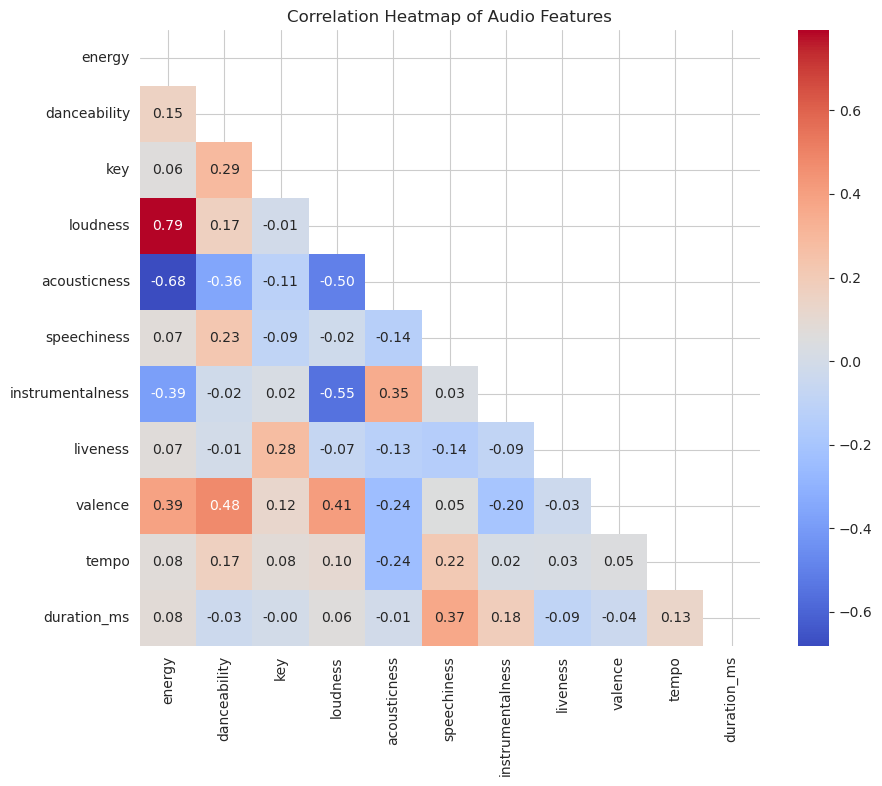

In [30]:

corr = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10,8))
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Audio Features")
plt.show()

## Strong Positive Correlations

We identify pairs of features with strong positive correlations (greater than 0.7).

In [31]:
corr_matrix = df.corr(numeric_only=True)

strong_positive = corr_matrix[(corr_matrix > 0.7) & (corr_matrix < 1)]

strong_positive

,energy,danceability,key,loudness,acousticness,speechiness,instrumentalness,liveness,valence,tempo,duration_ms
energy,NaN,NaN,NaN,0.79164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
key,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loudness,0.79164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
acousticness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
speechiness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
instrumentalness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
liveness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
valence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tempo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Loudness and Energy: 0.792
This significant correlation suggests that louder tracks in the Top 50 tend to have higher energy levels, which aligns with music production principles where dynamic, energetic songs often feature stronger volume levels. The correlation of 0.792 indicates that these features typically increase or decrease together.

## Strong Negative Correlations

Next, we identify features with strong negative correlations (less than -0.7).

In [32]:
strong_negative = corr_matrix[corr_matrix < -0.7]

strong_negative

,energy,danceability,key,loudness,acousticness,speechiness,instrumentalness,liveness,valence,tempo,duration_ms
energy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
key,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loudness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
acousticness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
speechiness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
instrumentalness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
liveness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
valence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tempo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


No strong negative correlations were found.

## Features With Weak or No Correlation

Features with correlation values close to zero are considered weakly correlated or not correlated.

In [33]:
weak_correlation = corr_matrix[(corr_matrix > -0.1) & (corr_matrix < 0.1)]

weak_correlation

,energy,danceability,key,loudness,acousticness,speechiness,instrumentalness,liveness,valence,tempo,duration_ms
energy,NaN,NaN,0.062428,NaN,NaN,0.074267,NaN,0.069487,NaN,0.075191,0.081971
danceability,NaN,NaN,NaN,NaN,NaN,NaN,-0.017706,-0.006648,NaN,NaN,-0.033763
key,0.062428,NaN,NaN,-0.009178,NaN,-0.094965,0.020802,NaN,NaN,0.080475,-0.003345
loudness,NaN,NaN,-0.009178,NaN,NaN,-0.021693,NaN,-0.069939,NaN,NaN,0.064130
acousticness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.010988
speechiness,0.074267,NaN,-0.094965,-0.021693,NaN,NaN,0.028948,NaN,0.053867,NaN,NaN
instrumentalness,NaN,-0.017706,0.020802,NaN,NaN,0.028948,NaN,-0.087034,NaN,0.018853,NaN
liveness,0.069487,-0.006648,NaN,-0.069939,NaN,NaN,-0.087034,NaN,-0.033366,0.025457,-0.090188
valence,NaN,NaN,NaN,NaN,NaN,0.053867,NaN,-0.033366,NaN,0.045089,-0.039794
tempo,0.075191,NaN,0.080475,NaN,NaN,NaN,0.018853,0.025457,0.045089,NaN,NaN


The correlation matrix shows several feature pairs with correlation values close to zero. 
This indicates weak relationships between these variables, meaning that changes in one feature do not strongly affect the others.

## Danceability Comparison by Genre

Next, we compare the danceability scores between four genres:
Pop, Hip-Hop/Rap, Dance/Electronic, and Alternative/Indie.

In [34]:
selected_genres = ['Pop', 'Hip-Hop/Rap', 'Dance/Electronic', 'Alternative/Indie']

danceability_genres = df[df['genre'].isin(selected_genres)][['genre','danceability']]

danceability_genres.groupby('genre').mean()

,danceability
genre,
Alternative/Indie,0.661750
Dance/Electronic,0.755000
Hip-Hop/Rap,0.765538
Pop,0.677571


## Loudness Comparison by Genre

We now compare the loudness values between the selected genres.

In [35]:
loudness_genres = df[df['genre'].isin(selected_genres)][['genre','loudness']]

loudness_genres.groupby('genre').mean()

,loudness
genre,
Alternative/Indie,-5.421000
Dance/Electronic,-5.338000
Hip-Hop/Rap,-6.917846
Pop,-6.460357


## Acousticness Comparison by Genre

Finally, we compare the acousticness scores across the selected genres.

In [36]:
acousticness_genres = df[df['genre'].isin(selected_genres)][['genre','acousticness']]

acousticness_genres.groupby('genre').mean()

,acousticness
genre,
Alternative/Indie,0.583500
Dance/Electronic,0.099440
Hip-Hop/Rap,0.188741
Pop,0.323843


# Summary

In this project, the Spotify Top 50 Tracks dataset from 2020 was analyzed to explore patterns in popular music. The goal was to understand what characteristics appear frequently in successful songs by examining artist representation, genre distribution, and different audio features such as danceability, loudness, and acousticness.

The dataset contains **50 songs and 16 features** describing musical characteristics and track information. After cleaning the data and performing exploratory data analysis, several patterns were identified regarding artists, genres, and relationships between audio features.

# Main Findings

The analysis revealed several important observations.

- The dataset includes **40 unique artists**, which shows a good level of diversity among the Top 50 tracks. However, some artists appear multiple times, meaning they had more than one popular song during the year.

- **Pop is the most represented genre**, with **14 tracks in the Top 50**. Other genres such as Hip-Hop/Rap and Dance/Electronic also appear frequently, showing that popular music includes a variety of styles.

- Many songs have relatively high danceability scores. In fact, **30 tracks have a danceability score above 0.7**, suggesting that songs that are easy to dance to tend to perform well on streaming platforms.

- The correlation analysis shows a **strong positive relationship between energy and loudness (0.79)**. This means that songs with higher energy levels are usually louder.

- The duration of the songs ranges from about **2 minutes and 21 seconds to 5 minutes and 13 seconds**, which suggests that most popular tracks stay within a moderate length suitable for streaming.

# Possible Improvements

Although this analysis provides useful insights, several improvements could make the study more comprehensive.

## Data Expansion

- Include **Spotify Top 50 data from multiple years** to analyze long-term trends.
- Add **regional Top 50 charts** to compare music preferences across different countries.
- Incorporate additional data such as **stream counts, playlist placements, or listener demographics**.

## Additional Analysis

- Analyze **seasonal trends** in music popularity.
- Examine how **artist collaborations influence streaming success**.
- Perform **lyrics analysis** to identify common themes in popular songs.
- Study the relationship between **social media presence and track popularity**.

## Technical Improvements

- Develop **machine learning models** to predict song popularity using audio features.
- Create **interactive dashboards** to visualize the data more effectively.
- Compare song performance across **different music platforms** such as Spotify, Apple Music, and YouTube.

Overall, expanding the dataset and applying more advanced analysis techniques could provide deeper insights into the factors that influence music popularity on streaming platforms.